# 03 — Churn Prediction

**Goal:** Define churn, build and evaluate a classification model to predict which customers are likely to churn, and identify the key drivers.

**Churn Definition:** A customer is churned if they have not placed an order in the last 180 days (6 months).

**Inputs:** `../data/cleaned/rfm_segments.csv`  
**Output:** `../data/cleaned/churn_predictions.csv`

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)
from xgboost import XGBClassifier

CLEAN_PATH = '../data/cleaned/'
CHURN_DAYS = 180

rfm = pd.read_csv(CLEAN_PATH + 'rfm_segments.csv', parse_dates=['first_order', 'last_order'])
print(f'Loaded {len(rfm):,} customers')

Loaded 93,349 customers


## 2. Define Churn Label

Churn rate: 59.2%
churned
1    55249
0    38100
Name: count, dtype: int64


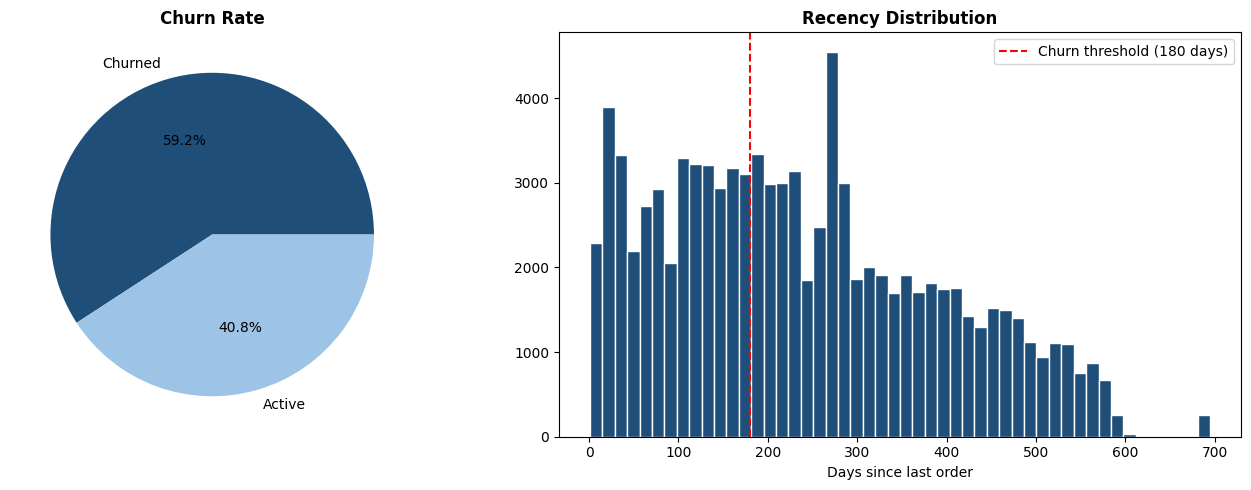

In [2]:
rfm['churned'] = (rfm['recency'] > CHURN_DAYS).astype(int)

churn_rate = rfm['churned'].mean() * 100
print(f'Churn rate: {churn_rate:.1f}%')
print(rfm['churned'].value_counts())

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rfm['churned'].value_counts().plot.pie(
    labels=['Churned', 'Active'], autopct='%1.1f%%',
    colors=['#1F4E79', '#9DC3E6'], ax=axes[0]
)
axes[0].set_title('Churn Rate', fontweight='bold')
axes[0].set_ylabel('')

axes[1].hist(rfm['recency'], bins=50, color='#1F4E79', edgecolor='white')
axes[1].axvline(CHURN_DAYS, color='red', linestyle='--', label=f'Churn threshold ({CHURN_DAYS} days)')
axes[1].set_title('Recency Distribution', fontweight='bold')
axes[1].set_xlabel('Days since last order')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/03_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Feature Engineering

In [3]:
# Encode categorical features
le = LabelEncoder()
rfm['segment_encoded'] = le.fit_transform(rfm['Segment'])
rfm['top_category_encoded'] = le.fit_transform(rfm['top_category'].fillna('unknown'))
rfm['state_encoded'] = le.fit_transform(rfm['state'].fillna('unknown'))

FEATURES = [
    'frequency', 'monetary', 'avg_order_value',
    'avg_review_score', 'R', 'F', 'M', 'RFM_Total',
    'segment_encoded', 'top_category_encoded', 'state_encoded'
]

# Fill any remaining nulls
for col in FEATURES:
    rfm[col] = rfm[col].fillna(rfm[col].median())

X = rfm[FEATURES]
y = rfm['churned']

print(f'Feature matrix: {X.shape}')
print(f'Target balance: {y.value_counts().to_dict()}')

Feature matrix: (93349, 11)
Target balance: {1: 55249, 0: 38100}


## 4. Train / Test Split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')

Train: 74,679 | Test: 18,670


## 5. Train & Compare Models

In [5]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=500),
    'Random Forest':        RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost':              XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss', verbosity=0)
}

results = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    X_tr = X_train_scaled if name == 'Logistic Regression' else X_train
    X_te = X_test_scaled if name == 'Logistic Regression' else X_test

    cv_scores = cross_val_score(model, X_tr, y_train, cv=cv, scoring='roc_auc')
    model.fit(X_tr, y_train)
    y_pred_proba = model.predict_proba(X_te)[:, 1]
    y_pred = model.predict(X_te)
    auc = roc_auc_score(y_test, y_pred_proba)

    results[name] = {
        'model': model,
        'cv_auc_mean': cv_scores.mean(),
        'cv_auc_std': cv_scores.std(),
        'test_auc': auc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    print(f'{name}: CV AUC = {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f}) | Test AUC = {auc:.4f}')

Logistic Regression: CV AUC = 0.9974 (+/- 0.0002) | Test AUC = 0.9973
Random Forest: CV AUC = 0.9960 (+/- 0.0005) | Test AUC = 0.9949
XGBoost: CV AUC = 0.9974 (+/- 0.0002) | Test AUC = 0.9973


## 6. Evaluate Best Model

In [7]:
# Select best model by test AUC
best_name = max(results, key=lambda k: results[k]['test_auc'])
best = results[best_name]
print(f'Best model: {best_name} (AUC: {best["test_auc"]:.4f})')
print()
print(classification_report(y_test, best['y_pred'], target_names=['Active', 'Churned']))

Best model: XGBoost (AUC: 0.9973)

              precision    recall  f1-score   support

      Active       1.00      0.98      0.99      7620
     Churned       0.99      1.00      0.99     11050

    accuracy                           0.99     18670
   macro avg       0.99      0.99      0.99     18670
weighted avg       0.99      0.99      0.99     18670



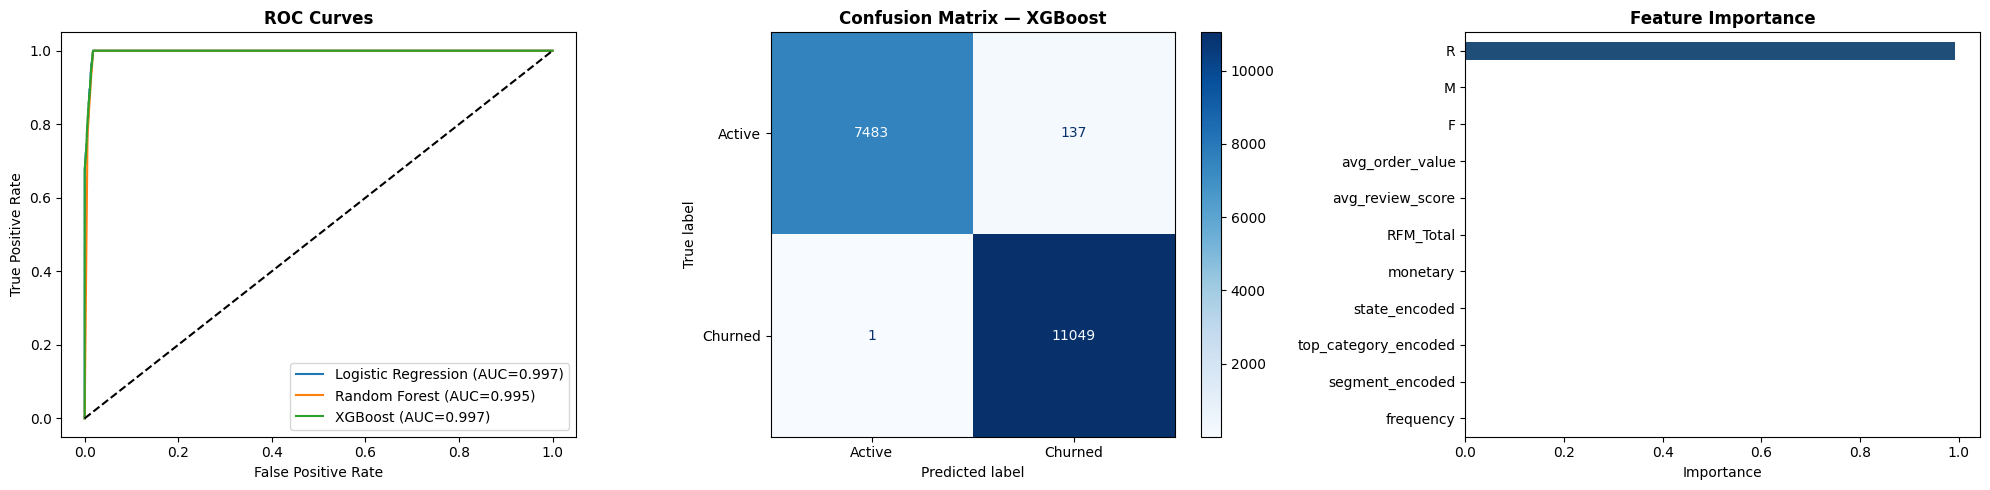

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# ROC curves for all models
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_pred_proba'])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={res['test_auc']:.3f})")
axes[0].plot([0, 1], [0, 1], 'k--')
axes[0].set_title('ROC Curves', fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, best['y_pred'],
    display_labels=['Active', 'Churned'],
    cmap='Blues', ax=axes[1]
)
axes[1].set_title(f'Confusion Matrix — {best_name}', fontweight='bold')

# Feature importance (if tree-based)
if hasattr(best['model'], 'feature_importances_'):
    importances = pd.Series(best['model'].feature_importances_, index=FEATURES)
    importances.sort_values().plot.barh(ax=axes[2], color='#1F4E79')
    axes[2].set_title('Feature Importance', fontweight='bold')
    axes[2].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('../reports/03_churn_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Save Churn Predictions

In [9]:
# Add churn probability to full dataset using best model
X_all = rfm[FEATURES].fillna(rfm[FEATURES].median())
if best_name == 'Logistic Regression':
    X_all_input = scaler.transform(X_all)
else:
    X_all_input = X_all

rfm['churn_probability'] = best['model'].predict_proba(X_all_input)[:, 1]
rfm['churn_risk'] = pd.cut(
    rfm['churn_probability'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low', 'Medium', 'High']
)

output_cols = ['customer_id', 'Segment', 'recency', 'frequency', 'monetary',
               'churned', 'churn_probability', 'churn_risk']
rfm[output_cols].to_csv(CLEAN_PATH + 'churn_predictions.csv', index=False)

print('Churn risk distribution:')
print(rfm['churn_risk'].value_counts())
print(f'\nSaved churn_predictions.csv')

Churn risk distribution:
churn_risk
High      55852
Low       37433
Medium       64
Name: count, dtype: int64

Saved churn_predictions.csv


## Summary

| Model | CV AUC | Test AUC |
|---|---|---|
| *(fill in from output above)* | | |

**Best Model:** *(fill in)*  
**Top Churn Drivers:** *(fill in from feature importance chart)*  
**High Risk Customers:** *(fill in count)*

**Next:** Run `04_clv_modelling.ipynb`